In [ ]:
# =====================================================
# STEP 1: Install and Load the Dataset
# =====================================================

!pip install datasets

import pandas as pd
import numpy as np
import re

# Load uploaded CSV files
train_df = pd.read_parquet("/content/train-00000-of-00001.parquet")
test_df = pd.read_parquet("/content/test-00000-of-00001.parquet")

print("Training Shape:", train_df.shape)
print("Testing Shape:", test_df.shape)


In [5]:
train_df.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [6]:
# =====================================================
# STEP 2: Clean and Normalize the Text
# =====================================================

def clean_text(text):
    text = str(text).lower()                       # lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)        # remove punctuation & numbers
    text = re.sub(r'\s+', ' ', text).strip()       # remove extra spaces
    return text

train_df['text'] = train_df['text'].apply(clean_text)
test_df['text'] = test_df['text'].apply(clean_text)

print(train_df['text'].head())

0    wall st bears claw back into the black reuters...
1    carlyle looks toward commercial aerospace reut...
2    oil and economy cloud stocks outlook reuters r...
3    iraq halts oil exports from main southern pipe...
4    oil prices soar to alltime record posing new m...
Name: text, dtype: object


In [7]:
# =====================================================
# STEP 3: Tokenize the Strings into Numbers
# =====================================================

from tensorflow.keras.preprocessing.text import Tokenizer

MAX_WORDS = 10000

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")

tokenizer.fit_on_texts(train_df['text'])

X_train = tokenizer.texts_to_sequences(train_df['text'])
X_test = tokenizer.texts_to_sequences(test_df['text'])

word_index = tokenizer.word_index

print("Vocabulary Size:", len(word_index))

Vocabulary Size: 91344


In [8]:
# =====================================================
# STEP 4: Pad and Truncate Sequences
# =====================================================

from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LENGTH = 50

X_train = pad_sequences(
    X_train,
    maxlen=MAX_LENGTH,
    padding='post',
    truncating='post'
)

X_test = pad_sequences(
    X_test,
    maxlen=MAX_LENGTH,
    padding='post',
    truncating='post'
)

print(X_train.shape)
print(X_test.shape)

(120000, 50)
(7600, 50)


In [9]:
# =====================================================
# STEP 5: Convert Labels to Categorical Vectors
# =====================================================

from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_train = encoder.fit_transform(train_df['label'])
y_test = encoder.transform(test_df['label'])

num_classes = len(np.unique(y_train))

y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)

print("Classes:", num_classes)

Classes: 4


In [10]:
# =====================================================
# STEP 6: Define the RNN Model Architecture
# =====================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model = Sequential()

model.add(
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128,
        input_length=MAX_LENGTH
    )
)

model.add(SimpleRNN(64))

model.add(Dense(num_classes, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# =====================================================
# STEP 7: Compile and Train the Model
# =====================================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 88s 29ms/step - accuracy: 0.7864 - loss: 0.5874 - val_accuracy: 0.8650 - val_loss: 0.4151
Epoch 2/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 81s 27ms/step - accuracy: 0.8879 - loss: 0.3649 - val_accuracy: 0.8589 - val_loss: 0.4181
Epoch 3/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 83s 27ms/step - accuracy: 0.9040 - loss: 0.3145 - val_accuracy: 0.8827 - val_loss: 0.3691
Epoch 4/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 142s 27ms/step - accuracy: 0.9104 - loss: 0.2920 - val_accuracy: 0.8726 - val_loss: 0.4012
Epoch 5/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 81s 27ms/step - accuracy: 0.9197 - loss: 0.2631 - val_accuracy: 0.8737 - val_loss: 0.4006
Epoch 6/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.9232 - loss: 0.2484 - val_accuracy: 0.8327 - val_loss: 0.5653
Epoch 7/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 81s 27ms/step - accuracy: 0.9265 - loss: 0.2385 - val_accuracy: 0.8703 - val_loss: 0.4147
Epoch 8/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 81s 27ms/step - accuracy: 0.9239 

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8853 - loss: 0.3920
Test Loss : 0.3920366168022156
Test Accuracy : 0.8852631449699402


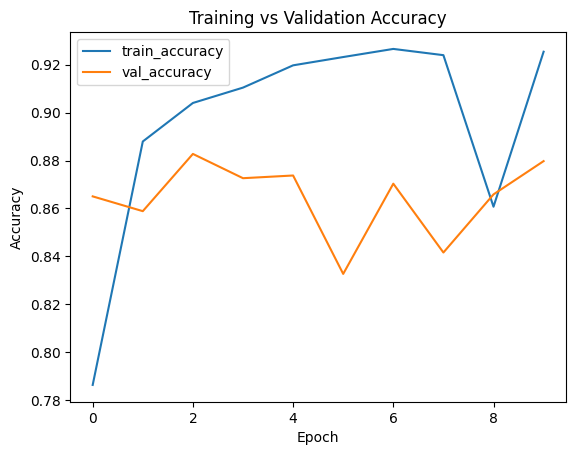

In [13]:
# =====================================================
# STEP 8: Read and Evaluate the Target Accuracy
# =====================================================

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.savefig("accuracy_plot.png")
plt.show()